Demonstration notebook for the use of the connect_pois function, with heavy reference to https://towardsdatascience.com/connecting-pois-to-a-road-network-358a81447944

In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
import pandana as pdna
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import sys
sys.path.append(r'C:\Users\z3258367\OneDrive - UNSW\#PhD\Walkability\WalkTHERE\there\src\there')
from connect_pois_optimised import connect_poi_optimised
from index import there_index
import pois as p

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import network

In [449]:
place = "Sutherland Shire, Australia"
proj_crs = "EPSG:28355"  # GDA94 / MGA zone 55
place_gdf = ox.geocode_to_gdf(place).to_crs(proj_crs)
G = ox.graph.graph_from_polygon(place_gdf.to_crs('EPSG:4326').geometry[0], network_type='walk')

In [450]:
G_proj = ox.projection.project_graph(G, to_crs=proj_crs)
print(ox.stats.intersection_count(G_proj, min_streets=2))
G_proj = ox.simplification.consolidate_intersections(G_proj, tolerance=10, rebuild_graph=True, dead_ends=False)
print(ox.stats.intersection_count(G_proj, min_streets=2))

# Get nodes and edges as geodataframes (gdfs) from OSMNX network
graph_df = ox.graph_to_gdfs(G_proj)
nodes_gdfs = graph_df[0]
edges_gdfs = graph_df[1]

edges_gdfs = edges_gdfs.to_crs(proj_crs)
nodes_gdfs = nodes_gdfs.to_crs(proj_crs)

14117
5252


The next few cells are further pre-processing for connect pois.

In [ ]:
# This isn't strictly necessary but reduces the overall network size by for example removing road lanes that have parallel footpaths
def simplify_edges(edges_gdfs):
    # where edges have the same u, v, keep only the one with 'highway' = 'footway', otherwise keep the first one
    edges_gdfs = edges_gdfs.reset_index()
    edges_gdfs = edges_gdfs.sort_values(by=['u','v','highway','length'])
    edges_gdfs = edges_gdfs.drop_duplicates(subset=['u', 'v'], keep='first')
    return edges_gdfs

In [451]:
edges_clean = edges_gdfs.copy()
nodes_clean = nodes_gdfs.copy()

edges_clean = edges_clean[['osmid','highway','length', 'geometry']]

# where edges_clean.osmid is a series of lists, e.g. [12345, 67890], change to just the first element of the list
edges_clean['osmid'] = edges_clean['osmid'].apply(lambda x: x[0] if isinstance(x, list) else x)
edges_clean['highway'] = edges_clean['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)

edges_simplified = simplify_edges(edges_clean)
print(len(edges_clean), len(edges_simplified))

edges_simplified['to'] = edges_simplified['v']
edges_simplified['from'] = edges_simplified['u']

26996 22987


### Import property centres


In [456]:
# load properties as GDF
property_ctrs = gpd.read_file("C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Data\\FEB21_CadLite_ESRIShapefileorDBFfile_GDA2020_20210225100808\\NSW_PROPERTY_POLYGON_CENTROIDS.shp")

In [457]:
# set index as the key for connect pois, filter to chosen place, and make sure crs match
property_ctrs['key'] = property_ctrs.index
property_ctrs = property_ctrs.to_crs(proj_crs)
property_ctrs = property_ctrs.loc[property_ctrs.within(place_gdf.geometry[0])]

<AxesSubplot: >

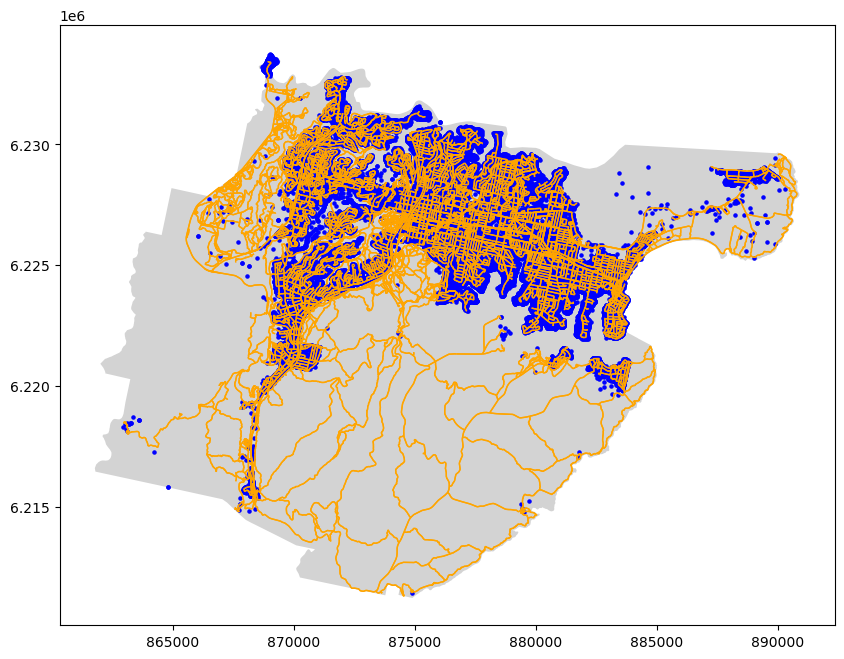

In [458]:
# plot place_gdf, property_ctrs, nodes and edges
fig, ax = plt.subplots(figsize=(10, 10))
place_gdf.plot(ax=ax, color='lightgrey')
edges_simplified.plot(ax=ax, color='orange', linewidth=1)
property_ctrs.plot(ax=ax, color='blue', markersize=5)
#nodes_gdfs.plot(ax=ax, color='green', markersize=5)

## Then actually run connect pois

In [468]:
# connect property centroids to the network
# The optimized function should now work properly with timing
import time

start_time = time.time()
new_nodes, new_edges = connect_poi_optimized(property_ctrs, nodes_clean, edges_simplified, key_col='key')
elapsed_time = time.time() - start_time

print(f"Successfully connected {len(property_ctrs)} POIs to the network")
print(f"Generated {len(new_nodes)} nodes and {len(new_edges)} edges")
print(f"Processing time: {elapsed_time:.2f} seconds")
print(f"Time per POI: {elapsed_time/len(property_ctrs):.3f} seconds")

Updating external nodes...
Projecting POIs to the network...
BallTree spatial indexing...
Updating internal nodes...
Creating coordinate lookup...
Updating internal edges...


c:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\shapely\linear.py:90: RuntimeWarning: invalid value encountered in line_locate_point
  return lib.line_locate_point(line, other)


22987 13385
Geometry duplicates: 0
Missing 'to' nodes: 18


c:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\geodataframe.py:2173: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:3857
Right CRS: None

  return geopandas.sjoin_nearest(
c:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\geodataframe.py:2173: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:3857
Right CRS: None

  return geopandas.sjoin_nearest(
c:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\geodataframe.py:2173: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:3857
Right CRS: None

  return geopanda

79487
Geometry duplicates: 2
Updating external links...
Missing 'to' nodes: 0
Remove faulty projections: 700/61988 (1.13%)
NOTE: duplication in node coordinates keys
Nodes count: 131716
Node coordinates key count: 125535
Missing 'from' nodes: 0
Missing 'to' nodes: 0
Successfully connected 61988 POIs to the network
Generated 131716 nodes and 140775 edges
Processing time: 331.37 seconds
Time per POI: 0.005 seconds


<AxesSubplot: >

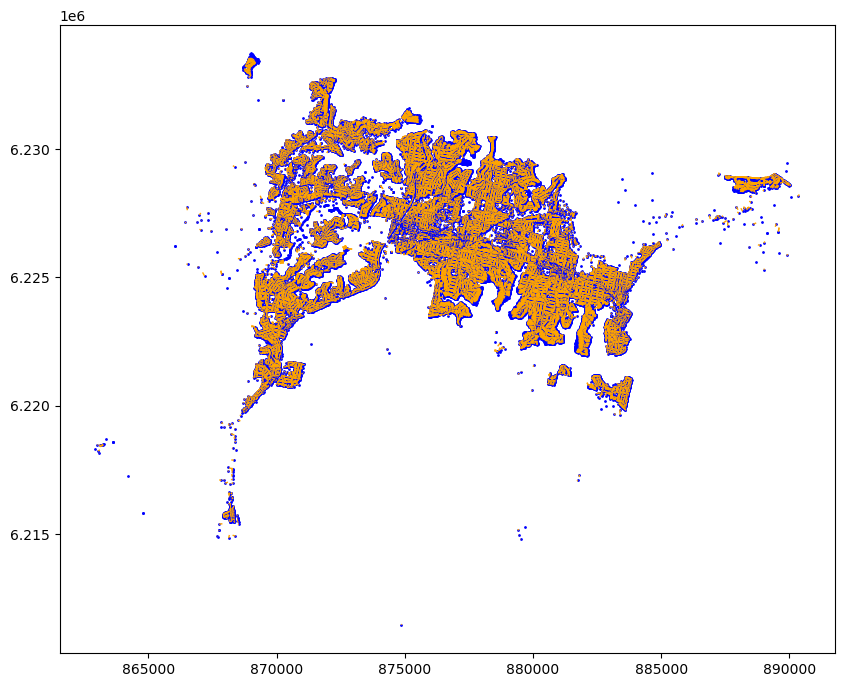

In [475]:
# plot with new edges and new nodes and property_ctrs
fig, ax = plt.subplots(figsize=(10, 10))
property_ctrs.plot(ax=ax, color='blue', markersize=1)
#new_nodes.plot(ax=ax, color='red', markersize=1)
new_edges[new_edges['connect_type']=='projected_footway'].plot(ax=ax, color='orange', linewidth=1)


## Check the results work with Pandana

In [ ]:
# get some pois to calculate accessibility with
poi_dict = p.get_poi_dict()
pois = p.poi_downloader(place, poi_dict, proj_crs=proj_crs)
params = p.default_poi_params()

In [ ]:
distance_network = pdna.Network(new_nodes.geometry.x, new_nodes.geometry.y,
                                   new_edges['from'], new_edges['to'], 
                                   new_edges[['length']])

distance=2500

index =  there_index(distance_network, pois, poi_dict, poi_weights = params['weight'], poi_gammas = params['distance_constant'], poi_nums = params['num_pois'], poi_lambdas = params['diminishing_returns_constant'], poi_variables = params['variable'], distance = distance, return_no=5, chain_frac=0)

No pois in category: employment
Finished category: employment
Maximum score: 0 out of 31.9
Finished category: education
Maximum score: 7.174920432833739 out of 14.3
Finished category: shopping
Maximum score: 15.425640435272705 out of 21.6
Finished category: errands
Maximum score: 6.322179594678346 out of 8.9
Finished category: recreation
Maximum score: 17.224063501711164 out of 23.3
